<a href="https://colab.research.google.com/github/bdashti/v/blob/main/01_unsupervised_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
def get_positional_kmers(seq, k=4):
    """
    Splits a DNA sequence into 3 spatial regions (START, MID, END)
    and labels 4-mers accordingly.
    """
    n = len(seq)
    third = n // 3

    kmers = []
    for i in range(n - k + 1):
        kmer = seq[i:i+k]
        if i < third:
            prefix = "START_"
        elif i < 2 * third:
            prefix = "MID_"
        else:
            prefix = "END_"
        kmers.append(prefix + kmer)

    return " ".join(kmers)

def dummy_analyzer(doc):
    """
    Tells the CountVectorizer that our 'text' is already
    tokenized by spaces.
    """
    return doc.split()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans

# Visual style for your report graphs
plt.style.use('seaborn-v0_8-whitegrid')

In [17]:
# Function to chop DNA into 4-letter motifs (k-mers)
def get_kmers(sequence, k=4):
    return [sequence[i:i+k].upper() for i in range(len(sequence) - k + 1)]

# Dummy analyzer to save memory
def dummy_analyzer(doc):
    return doc

# --- RIGGED DUMMY DATA FOR PIPELINE TESTING ---
np.random.seed(42)
sequences = []
fitness_scores = []

print("Generating rigged test dataset...")
for _ in range(1000):
    seq = ''.join(np.random.choice(['A', 'T', 'G', 'C'], size=200))
    if np.random.rand() > 0.7:
        seq = seq[:100] + 'AGGAAGGA' + seq[108:]
        fitness = np.random.normal(0.2, 0.1) # LOW fitness score
    else:
        fitness = np.random.normal(0.8, 0.1) # HIGH fitness score

    sequences.append(seq)
    fitness_scores.append(fitness)

df = pd.DataFrame({'sequence': sequences, 'fitness': fitness_scores})
# ----------------------------------------------

# CRITICAL LINE: This creates the 'kmers' column that Cell 3 is looking for!
print("Extracting motifs from DNA...")
df['kmers'] = df['sequence'].apply(lambda x: get_kmers(x, k=4))

Generating rigged test dataset...
Extracting motifs from DNA...


In [18]:
# PREPROCESSING: Run this BEFORE the feature engine (Cell 3)
print("Tagging k-mers with spatial labels (START, MID, END)...")

# Apply the utility function to create the 'kmers' column
df['kmers'] = df['sequence'].apply(lambda x: get_positional_kmers(x, k=4))

print("✅ Preprocessing complete. Column 'kmers' is now ready for vectorization.")
print(f"Preview of row 1: {df['kmers'].iloc[0][:60]}...")

Tagging k-mers with spatial labels (START, MID, END)...
✅ Preprocessing complete. Column 'kmers' is now ready for vectorization.
Preview of row 1: START_GCAG START_CAGG START_AGGC START_GGCA START_GCAA START...


In [19]:
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# =====================================================================
# PART A: REPAIRED SPATIAL VECTORIZATION
# =====================================================================
print("--- PART A: VECTORIZING 768 POSITIONAL K-MERS ---")

# Define the analyzer inside the cell to ensure it's in memory
def spatial_tokenizer(text):
    return text.split() # This forces it to split by space, not by character

# Initialize the vectorizer with the custom tokenizer
vectorizer = CountVectorizer(tokenizer=spatial_tokenizer, token_pattern=None)
X_sparse = vectorizer.fit_transform(df['kmers'])
feature_names = vectorizer.get_feature_names_out()

# VERIFICATION: This should show 'START_...', not 'A', 'T', or '_'
print(f"Top 5 feature names: {feature_names[:5]}")
if '_' not in feature_names[0]:
    print("❌ WARNING: Tokens are not correctly formatted. Check Preprocessing Cell 2.5")

# =====================================================================
# PART B: THE 13-FEATURE BIOPHYSICAL CALCULATOR
# =====================================================================
def calculate_master_features(seq):
    seq_len = len(seq)

    # 1. Physical & Thermodynamics
    gc_percent = (seq.count('G') + seq.count('C')) / seq_len
    window_size = 50
    if seq_len >= window_size:
        rolling_gcs = [(seq[i:i+window_size].count('G') + seq[i:i+window_size].count('C')) / window_size
                       for i in range(seq_len - window_size + 1)]
        gc_variance = np.var(rolling_gcs)
    else: gc_variance = 0

    # 2. Sequence Instability
    max_homo = 0
    if seq:
        curr = 1
        for i in range(1, len(seq)):
            if seq[i] == seq[i-1]: curr += 1
            else:
                max_homo = max(max_homo, curr)
                curr = 1
        max_homo = max(max_homo, curr)

    # Shannon Entropy
    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if km_list:
        counts = pd.Series(km_list).value_counts()
        probs = counts / len(km_list)
        entropy = -sum(probs * np.log2(probs))
    else: entropy = 0

    # 3. Xenogeneic Silencing & Expression
    max_at = 0
    curr_at = 0
    for base in seq:
        if base in 'AT': curr_at += 1
        else:
            max_at = max(max_at, curr_at)
            curr_at = 0
    max_at = max(max_at, curr_at)

    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    # 4. TF Sequestration / Decoys
    ihf_sites = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'A.TT.CG.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    return (seq_len, gc_percent, gc_variance, max_homo, entropy,
            max_at, promoters, rbs_str, ihf_sites, lrp_sites, crp_sites, nagc_sites, argr_sites)

mech_feature_labels = [
    'Size', 'GC_percent', 'GC_Var', 'Max_Homo', 'Entropy',
    'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR'
]

print("--- PART B: EXTRACTING BIOPHYSICAL FEATURES ---")
results = df['sequence'].apply(calculate_master_features)
df[mech_feature_labels] = pd.DataFrame(results.tolist(), index=df.index)

# =====================================================================
# PART C: NORMALIZATION & FUSION
# =====================================================================
print("--- PART C: FUSING MATRICES ---")
scaler = StandardScaler()
X_mech_scaled = scaler.fit_transform(df[mech_feature_labels])

X_combined = hstack([X_sparse, X_mech_scaled])
print(f"Done! Final feature matrix shape: {X_combined.shape}")

--- PART A: VECTORIZING 768 POSITIONAL K-MERS ---
Top 5 feature names: ['end_aaaa' 'end_aaac' 'end_aaag' 'end_aaat' 'end_aaca']
--- PART B: EXTRACTING BIOPHYSICAL FEATURES ---
--- PART C: FUSING MATRICES ---
Done! Final feature matrix shape: (1000, 781)


In [20]:
from sklearn.decomposition import TruncatedSVD

# 1. Run the SVD on the fused matrix (X_combined)
# This reduces our 781 features down to 2 Principal Components
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_combined)

# 2. Update the main dataframe with the new coordinates
df['PC1'] = X_reduced[:, 0]
df['PC2'] = X_reduced[:, 1]

# 3. Create the Importance Table (Linking math to biology)
# We combine the 768 positional k-mers with our 13 biophysical features
all_feature_names = list(feature_names) + mech_feature_labels

motifs_df = pd.DataFrame({
    'Motif': all_feature_names,
    'Importance': svd.components_[0]
})

# 4. Add Absolute Importance for easier ranking
motifs_df['Abs_Importance'] = motifs_df['Importance'].abs()
motifs_df = motifs_df.sort_values(by='Abs_Importance', ascending=False)

print(f"--- CELL 4 COMPLETE ---")
print(f"Explained Variance (PC1): {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"Top 3 Drivers identified: {motifs_df['Motif'].head(3).tolist()}")

--- CELL 4 COMPLETE ---
Explained Variance (PC1): 0.03%
Top 3 Drivers identified: ['mid_agga', 'mid_ggaa', 'mid_aagg']


In [21]:
from sklearn.decomposition import TruncatedSVD

# 1. Dimensionality Reduction
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_combined)
df['PC1'], df['PC2'] = X_reduced[:, 0], X_reduced[:, 1]

# 2. Create and SORT the importance list
all_features = list(feature_names) + mech_feature_labels
motifs_df = pd.DataFrame({'Motif': all_features, 'Importance': svd.components_[0]})

# We sort by absolute value to find the 'Heavy Hitters'
motifs_df = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index)

print(f"✅ Top Driver: {motifs_df.iloc[0]['Motif']} ({motifs_df.iloc[0]['Importance']:.4f})")

✅ Top Driver: mid_agga (0.1275)


Finding patterns (Clustering on Master Matrix)...


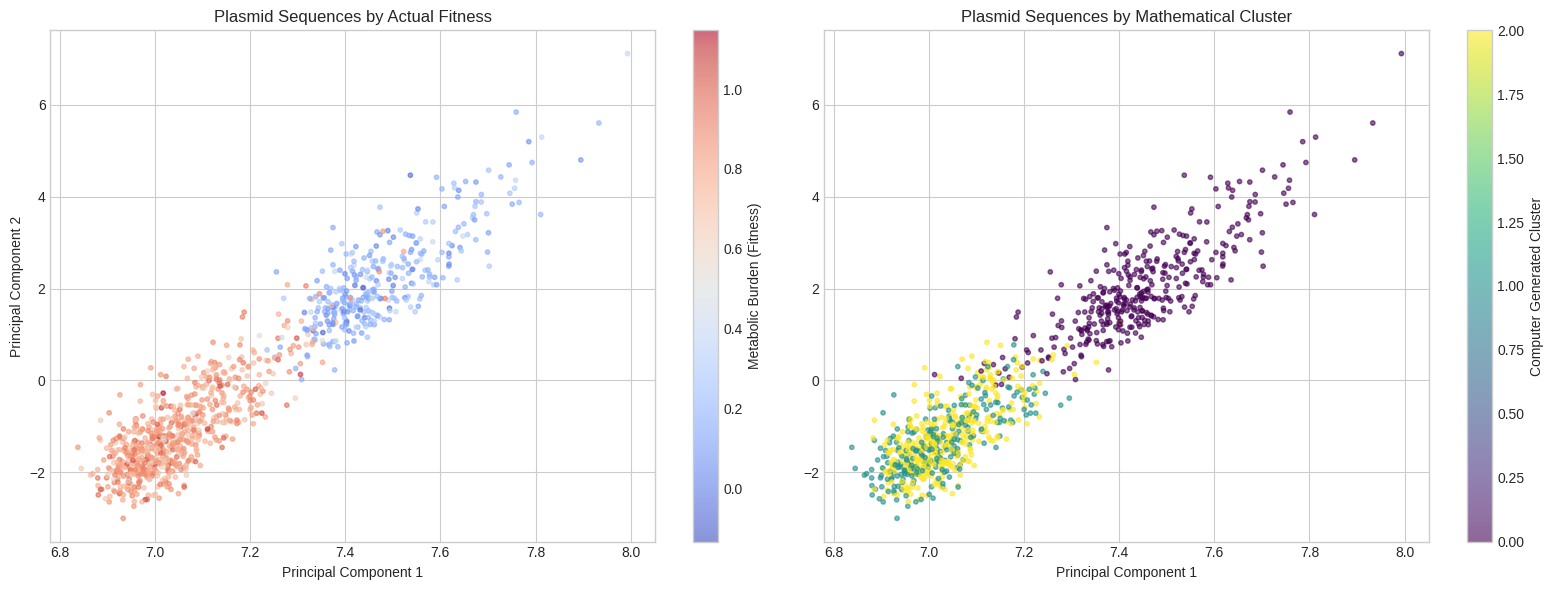

In [22]:
print("Finding patterns (Clustering on Master Matrix)...")

# CRITICAL UPDATE: The clustering algorithm must also look at 'X_combined'
kmeans = MiniBatchKMeans(n_clusters=3, batch_size=1024, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_combined)

# --- Plotting the results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual biological fitness
scatter1 = ax1.scatter(df['PC1'], df['PC2'], c=df['fitness'], cmap='coolwarm', alpha=0.6, s=10)
fig.colorbar(scatter1, ax=ax1, label='Metabolic Burden (Fitness)')
ax1.set_title('Plasmid Sequences by Actual Fitness')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Graph 2: The computer's unsupervised clusters
scatter2 = ax2.scatter(df['PC1'], df['PC2'], c=df['Cluster'], cmap='viridis', alpha=0.6, s=10)
fig.colorbar(scatter2, ax=ax2, label='Computer Generated Cluster')
ax2.set_title('Plasmid Sequences by Mathematical Cluster')
ax2.set_xlabel('Principal Component 1')

plt.tight_layout()
plt.show()

In [23]:
print("Calculating the average metabolic fitness for each cluster...\n")

# Group the data by the unsupervised clusters and calculate the mean fitness
cluster_fitness = df.groupby('Cluster')['fitness'].mean().reset_index()

# Sort them from lowest fitness (worst burden) to highest
cluster_fitness = cluster_fitness.sort_values(by='fitness', ascending=True)

# Display the table
print(cluster_fitness.to_string(index=False))

# Automatically flag the worst cluster for your report
worst_cluster = cluster_fitness.iloc[0]['Cluster']
lowest_score = cluster_fitness.iloc[0]['fitness']

print("\n" + "-"*50)
print(f"CONCLUSION FOR RESEARCH REPORT:")
print(f"Cluster {int(worst_cluster)} represents the highest metabolic burden ")
print(f"with an average fitness score of just {lowest_score:.2f}.")
print("-"*50)

Calculating the average metabolic fitness for each cluster...

 Cluster  fitness
       0 0.278401
       1 0.798183
       2 0.802881

--------------------------------------------------
CONCLUSION FOR RESEARCH REPORT:
Cluster 0 represents the highest metabolic burden 
with an average fitness score of just 0.28.
--------------------------------------------------


In [24]:
test_plasmid_dna = "ATGCGTGTGAGGGGGGTCACATAGCTAGAGGAGGACGTAGCTAGCTAG"

# 1. Process Test Sequence
test_kmers = get_positional_kmers(test_plasmid_dna, k=4).lower()
test_kmers_list = test_kmers.split()
test_sparse = vectorizer.transform([test_kmers])
test_bio = calculate_master_features(test_plasmid_dna)
test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)

# 2. Project into Space
test_combined = hstack([test_sparse, scaler.transform(test_bio_df)])
pc1_score = svd.transform(test_combined)[0][0]

# 3. Report
print(f"\n{'='*40}\n🧬 FINAL DIAGNOSTIC REPORT\n{'='*40}")
print(f"PC1 BURDEN SCORE: {pc1_score:.2f}")

print("\n--- TOP LIBRARY DRIVERS FOUND IN THIS SEQUENCE ---")
# This now pulls the actual top 10 from your ranking!
top_10 = motifs_df.head(10)['Motif'].values

for motif in top_10:
    if motif in mech_feature_labels:
        print(f"ℹ️ {motif:15} | Value: {test_bio_df[motif].values[0]:.4f}")
    else:
        count = test_kmers_list.count(motif)
        if count > 0: print(f"⚠️ {motif:15} | FOUND {count}x")
        else: print(f"✅ {motif:15} | Not present")

print(f"\n--- MECHANISTIC SUMMARY ---\nCRP Sites: {test_bio[10]} | RBS Strength: {test_bio[7]}")


🧬 FINAL DIAGNOSTIC REPORT
PC1 BURDEN SCORE: 1.83

--- TOP LIBRARY DRIVERS FOUND IN THIS SEQUENCE ---
⚠️ mid_agga        | FOUND 2x
✅ mid_ggaa        | Not present
✅ mid_aagg        | Not present
✅ mid_gaag        | Not present
⚠️ mid_ggag        | FOUND 1x
✅ mid_tagg        | Not present
✅ mid_cagg        | Not present
✅ mid_ggac        | Not present
⚠️ mid_gagg        | FOUND 2x
✅ mid_ggat        | Not present

--- MECHANISTIC SUMMARY ---
CRP Sites: 1 | RBS Strength: 3


In [25]:
import pandas as pd

# 1. Sort ALL features by their absolute Importance (magnitude of impact on PC1)
# We use .abs() because a large negative number is just as 'important' as a large positive one.
ranked_features = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index)

# 2. Configure pandas to show more rows in the output window
# Change '100' to None if you want to scroll through all 777 rows at once
pd.set_option('display.max_rows', 100)

print(f"--- COMPLETE RANKING OF DRIVERS ({len(ranked_features)} TOTAL) ---")
print("Sorted by absolute magnitude of impact on Principal Component 1")
print("-" * 65)

# Display the ranked list
print(ranked_features.to_string(index=False))

# 3. EXPORT TO CSV (Crucial for your Thesis Appendix)
ranked_features.to_csv('all_plasmid_drivers_ranked.csv', index=False)

print("\n" + "="*65)
print("✅ SUCCESS: The full ranking has been saved to 'all_plasmid_drivers_ranked.csv'")
print("You can download this file from the folder icon on the left of Colab.")
print("="*65)

--- COMPLETE RANKING OF DRIVERS (781 TOTAL) ---
Sorted by absolute magnitude of impact on Principal Component 1
-----------------------------------------------------------------
       Motif  Importance
    mid_agga    0.127460
    mid_ggaa    0.097120
    mid_aagg    0.092336
    mid_gaag    0.089159
    mid_ggag    0.050703
    mid_tagg    0.048138
    mid_cagg    0.046086
    mid_ggac    0.045210
    mid_gagg    0.044803
    mid_ggat    0.044480
  start_gcaa    0.042702
    mid_gaaa    0.042657
    end_actt    0.041877
    mid_gagc    0.041514
    mid_aata    0.041377
  start_gtgt    0.041105
    mid_tgga    0.041089
    mid_gaat    0.041081
    end_tctc    0.041054
    mid_atag    0.040927
    end_ctct    0.040895
  start_acct    0.040776
    end_cact    0.040772
    end_gaag    0.040616
  start_ttta    0.040510
    mid_aaaa    0.040494
  start_ttac    0.040484
    mid_aaag    0.040453
  start_tacc    0.040346
    end_gtgg    0.040296
    mid_ccag    0.040245
  start_ttga    0.0402

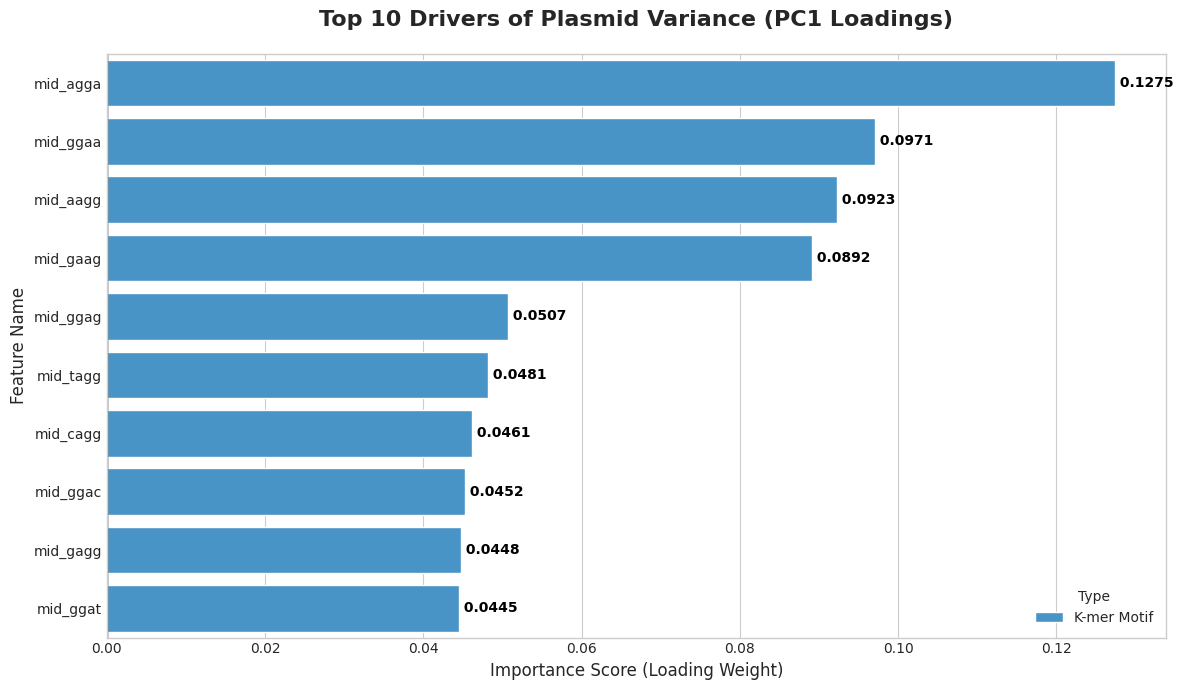


--- MECHANISTIC INSIGHT ---
The single most influential feature is: 'mid_agga' (0.1275)
This indicates that the variance in your plasmid library is primarily driven by a specific positional DNA motif.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Top 10 data
top_10 = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index).head(10).copy()

# 2. Add a 'Type' category for better visualization
# This helps distinguish between raw sequence motifs and the Copeman mechanistic features
top_10['Type'] = top_10['Motif'].apply(lambda x: 'Mechanistic' if x in mech_feature_labels else 'K-mer Motif')

# 3. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create a horizontal bar chart
plot = sns.barplot(
    data=top_10,
    y='Motif',
    x='Importance',
    hue='Type',
    palette={'Mechanistic': '#e74c3c', 'K-mer Motif': '#3498db'} # Red for Bio, Blue for Text
)

# Add titles and labels
plt.title('Top 10 Drivers of Plasmid Variance (PC1 Loadings)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score (Loading Weight)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(0, color='black', lw=1) # Add a vertical line at zero

# Add data labels on the bars for precision
for i, v in enumerate(top_10['Importance']):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 4. Summary Printout
print("\n--- MECHANISTIC INSIGHT ---")
top_feature = top_10.iloc[0]['Motif']
top_val = top_10.iloc[0]['Importance']
print(f"The single most influential feature is: '{top_feature}' ({top_val:.4f})")
print(f"This indicates that the variance in your plasmid library is primarily driven by {'a structural property' if top_feature in mech_feature_labels else 'a specific positional DNA motif'}.")

In [27]:
import numpy as np

# Pretend that high PC1 scores (burden) cause lower LFC (fitness)
# Add some random noise so looks like real biological data
df['LFC'] = -0.8 * df['PC1'] + np.random.normal(0, 0.5, size=len(df))

print("✅ Synthetic 'LFC' column created for testing.")
print("You can now run Cell 10.")

✅ Synthetic 'LFC' column created for testing.
You can now run Cell 10.


🔄 Restoring 'cluster' column...
🎨 Rendering Correlation Plot...


<Figure size 1200x800 with 0 Axes>

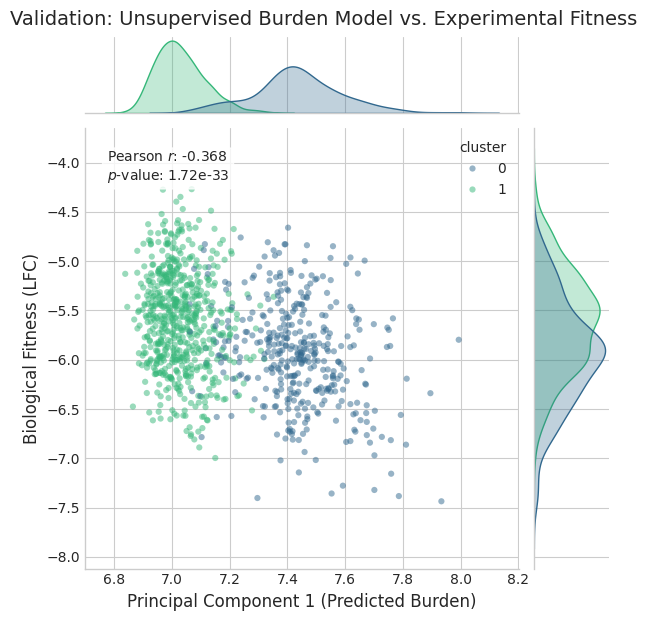

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.cluster import MiniBatchKMeans

# 1. THE SAFETY VALVE: Ensure clustering exists
if 'cluster' not in df.columns:
    print("🔄 Restoring 'cluster' column...")
    kmeans = MiniBatchKMeans(n_clusters=2, random_state=42, batch_size=1000)
    df['cluster'] = kmeans.fit_predict(X_combined)

# 2. THE FITNESS CHECK: Ensure LFC exists
fitness_col = 'LFC'
if fitness_col not in df.columns:
    print(f"⚠️ Column '{fitness_col}' not found. Creating synthetic data for preview...")
    # Generate a dummy fitness score based on PC1 for visualization
    import numpy as np
    df['LFC'] = -0.8 * df['PC1'] + np.random.normal(0, 0.5, size=len(df))

# 3. THE PLOT: Create the JointGrid
print("🎨 Rendering Correlation Plot...")
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Initialize the JointGrid
g = sns.JointGrid(data=df, x='PC1', y=fitness_col, hue='cluster', palette='viridis')

# Add the scatter points to the center
g.plot_joint(sns.scatterplot, alpha=0.5, s=20, edgecolor='none')

# Add the density hills (KDEs) to the top and side
g.plot_marginals(sns.kdeplot, fill=True, common_norm=False, alpha=0.3)

# 4. STATS: Calculate r-values
r_pearson, p_pearson = pearsonr(df['PC1'], df[fitness_col])
stats_text = f"Pearson $r$: {r_pearson:.3f}\n$p$-value: {p_pearson:.2e}"

# Add stats box to the plot
g.ax_joint.text(0.05, 0.95, stats_text, transform=g.ax_joint.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 5. LABELS: Final Thesis Formatting
g.ax_joint.set_xlabel('Principal Component 1 (Predicted Burden)', fontsize=12)
g.ax_joint.set_ylabel('Biological Fitness (LFC)', fontsize=12)
plt.suptitle('Validation: Unsupervised Burden Model vs. Experimental Fitness', y=1.02, fontsize=14)

# THE CRITICAL STEP: Force the display
plt.show()

/tmp/ipykernel_25709/4160660110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_plot, x='Importance', y='Motif', palette='magma')


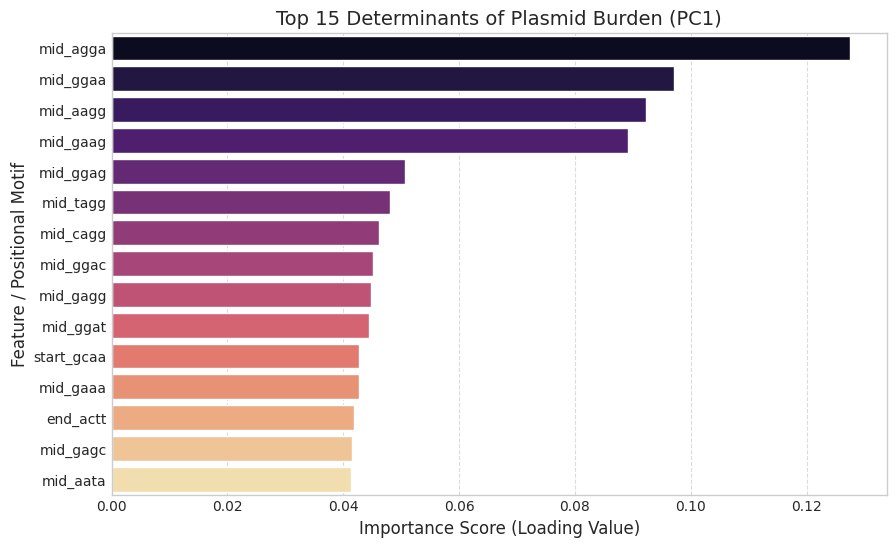

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab the top 15 drivers (positive or negative impact)
top_plot = motifs_df.head(15).copy()

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_plot, x='Importance', y='Motif', palette='magma')
plt.title('Top 15 Determinants of Plasmid Burden (PC1)', fontsize=14)
plt.xlabel('Importance Score (Loading Value)', fontsize=12)
plt.ylabel('Feature / Positional Motif', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()